<a href="https://colab.research.google.com/github/hosseinta2/LLM-from-scratch/blob/main/LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loading the dataset for instruction fine-tuning with LORA

import json
import os
import urllib
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data
file_path = "instruction-data.json"
url = (
"https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
"/main/ch07/01_main-chapter-code/instruction-data.json" )
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))


def format_input(entry): # full prompt+response;
    instruction_text = (f"Below is an instruction that describes a task. "
    f"Write a response that appropriately completes the request."
                        f"\n\n### Instruction:\n{entry['instruction']}"
          )
    input_text = (f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    response_text = f"\n\n### Response:\n{entry['output']}"
    return instruction_text + input_text + response_text

def format_input_only(entry): #  full prompt in string format
    instruction_text = (f"Below is an instruction that describes a task. "
    f"Write a response that appropriately completes the request."
                        f"\n\n### Instruction:\n{entry['instruction']}"
          )
    input_text = (f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text


train_data = data[:880]
test_data = data[880:]
import torch
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
padding_id = 50256

def padded(input, indices, padding_id=50256, ignore_index = -100, allowed_max_length = 1024):
  input_padded = []
  target_padded = []
  max_length = max(len(x)+1 for x in input)
  if max_length>allowed_max_length:
    max_length = allowed_max_length
  for i,x in enumerate(input):
    padded_x = x+(max_length-len(x))*[padding_id] # padding the remaining length of each input data
    padded_inst= [ignore_index] * (indices[i]) # masking the prompt for target
    padded_x2 = padded_inst + x[indices[i]:] + [padding_id]+(max_length-len(x)-1)*[ignore_index] # target = masked_prompt + response + one token to padding + masked rest
    input_padded.append(padded_x[:-1])
    target_padded.append(padded_x2[1:])
  return torch.tensor(input_padded),torch.tensor(target_padded)




train_data_list = []
test_data_list = []
indices_train = []
indices_test = []
for instruction in train_data:
  text = format_input(instruction)
  indices_train.append(len(tokenizer.encode(format_input_only(instruction))))# length of prompt for each data point; used for masking the prompt for target data
  tokenized_text = tokenizer.encode(text)
  train_data_list.append(tokenized_text)
for instruction in test_data:
  text = format_input(instruction)
  indices_test.append(len(tokenizer.encode(format_input_only(instruction)))) # length of prompt for each data point; used for masking the prompt for target data
  tokenized_text = tokenizer.encode(text)
  test_data_list.append(tokenized_text)
x_tr,y_tr = padded(train_data_list,indices_train)
x_te,y_te = padded(test_data_list,indices_test)

from torch.utils.data import Dataset, DataLoader,TensorDataset

batched_train_data = TensorDataset(x_tr,y_tr)
batched_test_data = TensorDataset(x_te,y_te)

training_batches = DataLoader(batched_train_data,batch_size=8,shuffle=True,drop_last=True)
test_batches = DataLoader(batched_test_data,batch_size=8,shuffle=False,drop_last=False)

In [ ]:
#Loading the base model

import urllib.request

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

from gpt_download import download_and_load_gpt2 #importing GPT2 OAI weights
from model_and_load_weight import GPT,load_weights_into_gpt #importing the model and the function to load gpt2 OAI weight



BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs["gpt2-medium (355M)"])

model_size = "355M"

settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)
model = GPT(BASE_CONFIG)
load_weights_into_gpt(model, params)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
  device = torch.device("mps")
print(device)
model.to(device)

In [ ]:

def generate_text(model,tokenized_text,max_new_context_size,context_size,temp,topk): # generating max_new_tokens for a text and a model with context_size,
                                                                           #used for testing the model's output during training
  for _ in range(max_new_context_size):
      ids = tokenized_text[:,-context_size:]
      logits = model(ids) #batch_size*context_size*vocab_size
      last_logit = logits[:,-1,:] #batch_size*vocab_size
      top_val,top_pos = torch.topk(last_logit,topk)
      last_logit = torch.where(condition = last_logit<top_val.squeeze(0)[-1],
                               input = torch.tensor(float('-inf')).to(last_logit.device),
                               other = last_logit)

      scores = torch.softmax(last_logit/temp,dim=-1) #batch_size*vocab_size
      #max_id = torch.argmax(scores,dim=-1, keepdim=True) #batch_size*1
      new_id = torch.multinomial(scores,num_samples=1)
      tokenized_text = torch.cat((tokenized_text,new_id),dim=-1)#cat(batch_size*len_context,batch_size*1)=batch_size * (len_context+1)
      if new_id==50256: # if end of text is reached break the generation
        break

  return tokenized_text

In [ ]:
# testing the model output
text = torch.tensor(tokenizer.encode("The best president of U.S. is")).unsqueeze(0).to(device)
out = generate_text(model,text,20,20,.5,10)
print(tokenizer.decode(list(out.squeeze())))

In [67]:
# the LoRA Layer

import math
import torch
import torch.nn as nn
model = GPT(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.to(device)
class LoRALayer(nn.Module):
  def __init__(self,in_dim,out_dim,rank,alpha):
     super().__init__()
     self.A = nn.Parameter(torch.empty(in_dim,rank))
     self.B = nn.Parameter(torch.zeros(rank,out_dim))
     torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
     self.alpha = alpha
     self.rank = rank
  def forward(self,x):
    out = self.alpha/self.rank *(x@self.A@self.B)
    return out

class LoRALayer_and_Linear (nn.Module):
  def __init__(self,linear,rank,alpha):
     super().__init__()
     self.linear =linear
     self.lora = LoRALayer(linear.in_features,linear.out_features,rank,alpha)
  def forward(self,x):
    return self.linear(x) + self.lora(x)

#def replace_linear_with_lora(model, rank, alpha):
#    for name, module in model.named_children():
#        if isinstance(module, torch.nn.Linear):
#          setattr(model, name, LoRALayer_and_Linear(module, rank, alpha))
#        else:
#            replace_linear_with_lora(module, rank, alpha)

def replace_attention_linear_with_lora(model, rank, alpha):
    target_names = {"W_q", "W_k", "W_v", "projection"}

    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear) and name in target_names:
            setattr(model, name, LoRALayer_and_Linear(module, rank, alpha))
        else:
            replace_attention_linear_with_lora(module, rank, alpha)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad==True)
print(total_params)

for p in model.parameters(): # freezing the original model's weights
  p.requires_grad =False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad==True)
print(total_params)

replace_attention_linear_with_lora(model,rank = 4,alpha=4) # replace linear weights with LORA+Linear
model.to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad==True)
print(total_params)

406286336
0
786432


In [68]:
import time
loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",      # validation loss should decrease
    factor=0.5,      # reduce lr by half
    patience=1,      # wait 1 evaluation before reducing
    min_lr=1e-7
)

def batch_loss(input,target,model,device):# cross_entropy loss for a batch of data
  input = input.to(device)
  target = target.to(device)
  output = model(input)
  output = output.flatten(0,1)
  target = target.flatten()
  loss_val = loss_func(output,target)
  return loss_val

train_loss,eval_loss =[],[]
steps = -1
freq = 50
num_epochs = 4

model.train()

start_time = time.time()
for epoch in range(num_epochs):
  for x,y in training_batches:
    optimizer.zero_grad()
    los = batch_loss(x,y,model,device)
    los.backward()
    optimizer.step()
    steps+=1
    if steps%freq==0: # evaluating the model
      model.eval()
      train_loss_value = 0
      val_loss_value = 0
      n_batches = 0
      with torch.no_grad():
        for train_x,train_y in training_batches:
          train_loss_value += batch_loss(train_x,train_y,model,device).item()
          n_batches +=1
          if n_batches>10:
            break
        train_loss_value  =  train_loss_value/n_batches
        n_batches = 0
        for val_x,val_y in test_batches:
          val_loss_value += batch_loss(val_x,val_y,model,device).item()
          n_batches +=1
        val_loss_value = val_loss_value/n_batches
        scheduler.step(val_loss_value) # see if validation decreased, then halve the lr
        current_lr = optimizer.param_groups[0]["lr"]
        sample_input = test_data[9]# seeing the model's output during training
        sample_input =format_input_only(sample_input)
        length_prompt= len(tokenizer.encode(sample_input))
        sample_padded,target_padded = padded([tokenizer.encode(sample_input)],[length_prompt])
        sample_padded =sample_padded.to(device)
        sample_out = generate_text(model,sample_padded,30,60,0.3,10)
        sample_out_text = tokenizer.decode(list(sample_out.squeeze()))
      train_loss.append(train_loss_value)
      eval_loss.append(val_loss_value)
      print("Epoch = ", epoch, "lr = ", current_lr, "train_loss = ", train_loss_value, "val_loss = ", val_loss_value,"\n",sample_out_text,"\n")
      model.train()
end_time = time.time()



print("total time = ", (end_time-start_time)/60)


Epoch =  0 lr =  0.0001 train_loss =  2.140562133355574 val_loss =  2.1854162897382463 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Edit the following sentence to make it more formal.

### Input:
He's got to see it to believe it.

### Output:

The problem is that the user has no idea what the problem is.

### Solution:

The solution 

Epoch =  0 lr =  0.0001 train_loss =  1.0353873805566267 val_loss =  1.0601852812937327 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Edit the following sentence to make it more formal.

### Input:
He's got to see it to believe it.<|endoftext|> 

Epoch =  0 lr =  0.0001 train_loss =  0.9323075359517877 val_loss =  0.9436199281896863 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Edit the following sentence to make it mo

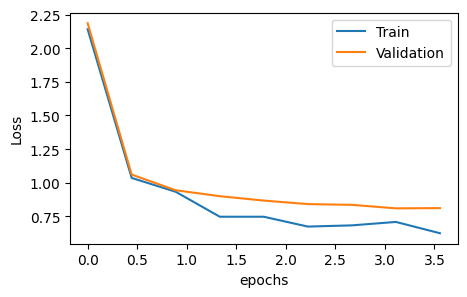

In [69]:
import matplotlib.pyplot as plt
x_axis = [i*num_epochs/len(train_loss) for i in range(len(train_loss))]
fig,ax = plt.subplots(figsize = (5,3))
ax.plot(x_axis,train_loss, label=f"Train")
ax.plot(x_axis, eval_loss,label =f"Validation")
ax.legend()
ax.set_xlabel("epochs")
ax.set_ylabel("Loss")
plt.show()